In [239]:
words = open(r"names.txt", 'r').read().splitlines()

In [240]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [241]:
import torch

In [242]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [243]:
chars = sorted(set(''.join(words)))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {b:a for a,b in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [244]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

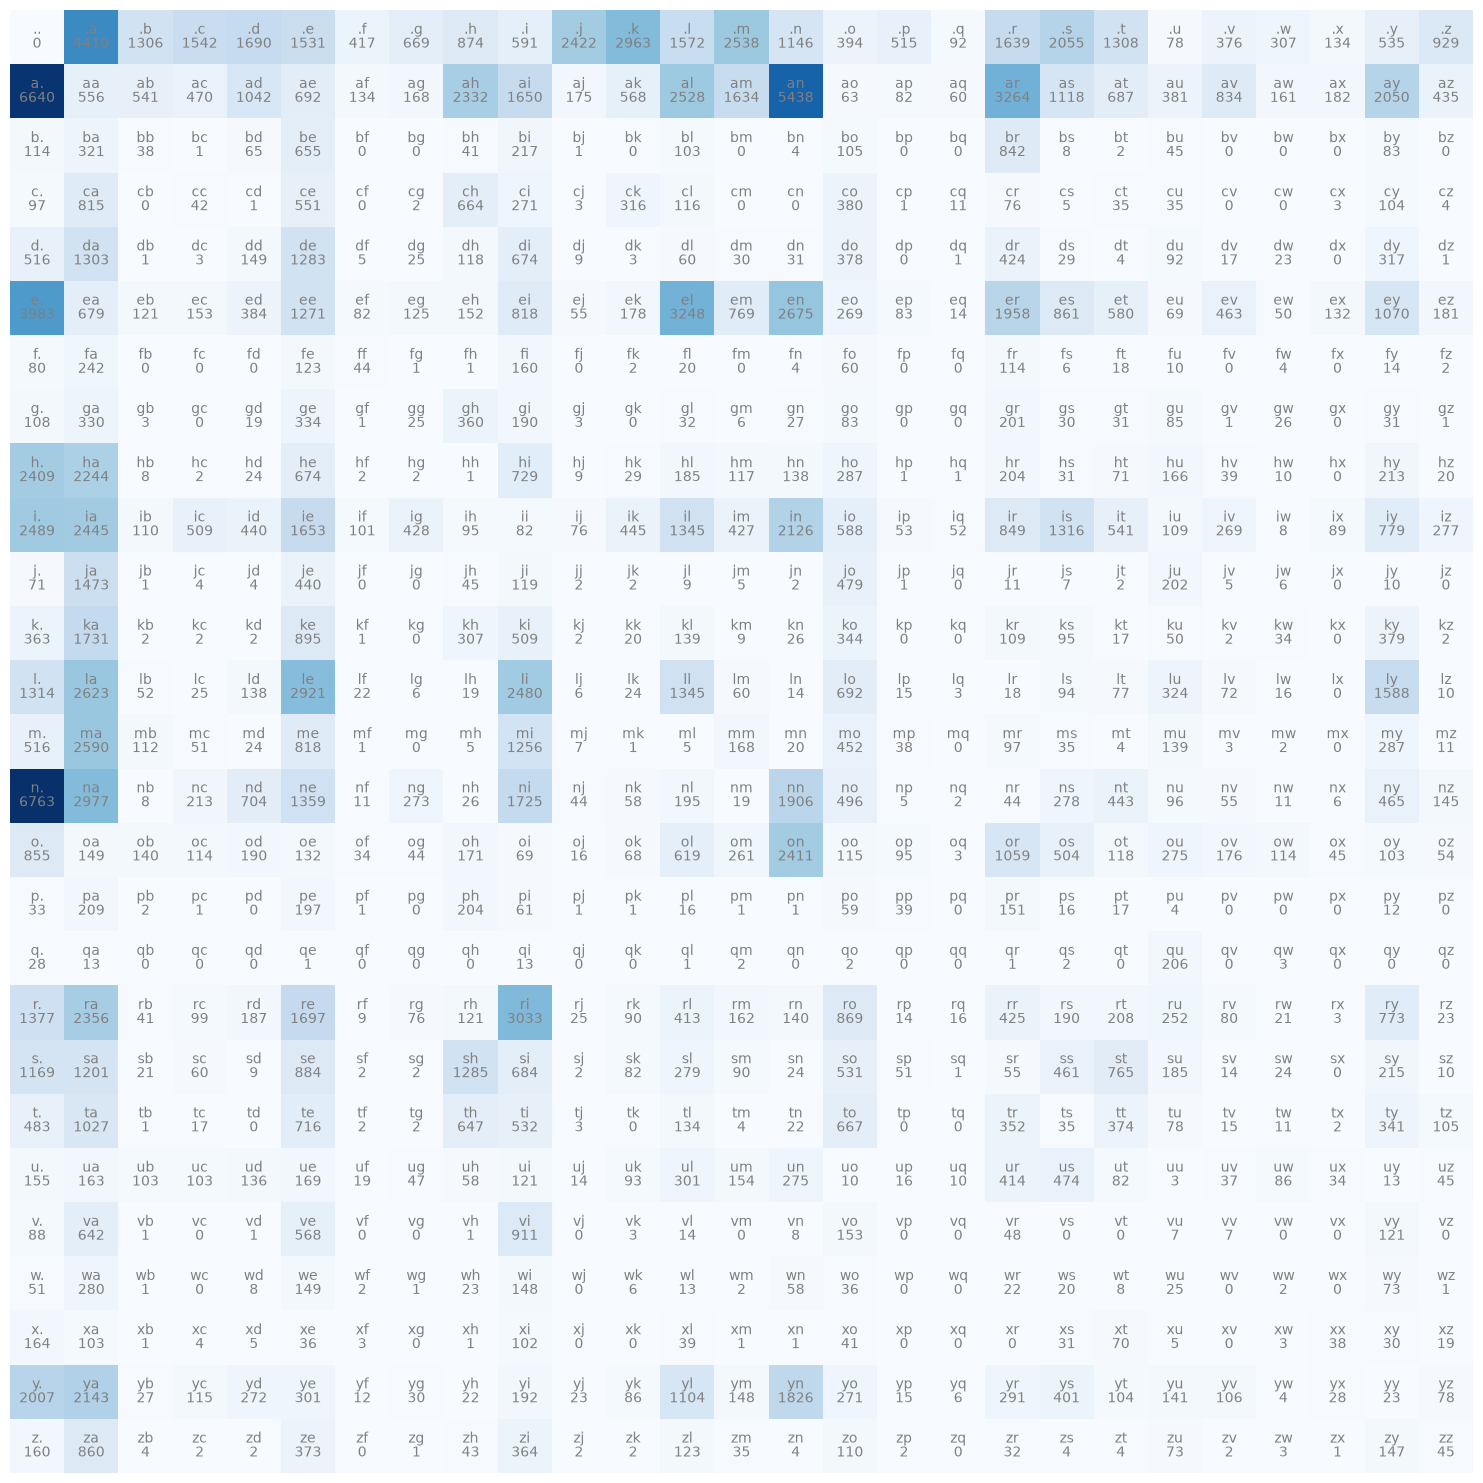

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(19,19))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color= 'gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color= 'gray')
plt.axis('off');

In [246]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)
# P.sum(1, keepdim=True).shape
P[0]

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

In [248]:
g = torch.Generator().manual_seed(2147483647)
for i in range(25):
    idx = 0
    out = []
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        out.append(itos[idx])
    print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
ftlspihinivenvorhlasu
dsor
br
jol
pen
aisan
ja
feniee
zem
deru
firit
gaikajahahbevare


In [10]:
ll = 0.0
n = 0.0

for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        ll += logprob
        n += 1
        print(f'{itos[ix1]}{itos[ix2]}:   {prob:.4f}   {logprob:.4f}')
print(f'Log Likelihood: {ll:.4f}')
nll = -ll
print(f'Negative Log Likelihood: {nll:.4f}')
print(f'Avg. Negative Log Likelihood: {(nll/n):.4f}')

.e:   0.0478   -3.0410
em:   0.0377   -3.2793
mm:   0.0253   -3.6753
ma:   0.3885   -0.9454
a.:   0.1958   -1.6305
.o:   0.0123   -4.3965
ol:   0.0779   -2.5526
li:   0.1774   -1.7293
iv:   0.0152   -4.1845
vi:   0.3508   -1.0476
ia:   0.1380   -1.9807
a.:   0.1958   -1.6305
.a:   0.1376   -1.9835
av:   0.0246   -3.7041
va:   0.2473   -1.3971
a.:   0.1958   -1.6305
Log Likelihood: -38.8086
Negative Log Likelihood: 38.8086
Avg. Negative Log Likelihood: 2.4255


In [90]:
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [91]:
xs

tensor([ 0,  5, 13, 13,  1])

In [77]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc.shape

torch.Size([5, 27])

In [78]:
xenc.dtype

torch.float32

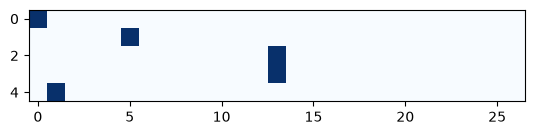

In [79]:
plt.imshow(xenc, cmap='Blues')

In [50]:
W = torch.randn((27,27))
xenc @ W

tensor([[-1.0123e+00,  4.7727e-01, -2.7776e-01,  2.7998e-01,  3.7620e-01,
         -7.1122e-01,  5.3377e-01, -8.4360e-01,  1.2187e-01,  1.2020e+00,
          4.4218e-01, -1.7781e+00,  2.0786e+00,  1.2477e+00, -1.6814e+00,
         -2.0464e+00,  9.0423e-01, -9.4765e-01, -1.4914e+00,  1.5150e+00,
          6.9779e-01, -1.9707e-01, -2.2417e-01, -8.1683e-01, -7.4141e-01,
          1.4560e-01,  1.0581e+00],
        [ 6.7899e-01,  1.1468e+00,  1.2540e-01, -3.7166e-01, -1.7143e-01,
         -1.4793e+00, -1.4514e+00, -9.3143e-01,  3.9988e-01, -1.9817e+00,
          1.4556e+00, -2.7733e-01, -2.5267e-01, -1.2578e+00, -2.9532e-01,
         -3.1823e-01, -1.7794e-01, -1.9490e+00, -7.5842e-01,  1.4825e+00,
          3.2768e-01, -9.3219e-01,  6.2125e-01, -3.0053e-01,  1.6064e+00,
          1.1782e+00, -7.2234e-01],
        [ 1.6497e+00,  9.5357e-01, -1.2851e+00,  1.2682e+00, -6.3591e-01,
          2.1427e-01,  3.2119e-02,  1.4072e-01,  1.5164e+00,  9.8874e-01,
         -1.9170e+00,  1.7476e+00, -1.71

In [51]:
logits = (xenc@W) # log-count
counts = logits.exp() # N equivalents
prob = counts / counts.sum(1, keepdims=True)
prob

tensor([[0.0086, 0.0381, 0.0179, 0.0313, 0.0344, 0.0116, 0.0403, 0.0102, 0.0267,
         0.0786, 0.0368, 0.0040, 0.1888, 0.0823, 0.0044, 0.0031, 0.0584, 0.0092,
         0.0053, 0.1075, 0.0475, 0.0194, 0.0189, 0.0104, 0.0113, 0.0273, 0.0681],
        [0.0536, 0.0855, 0.0308, 0.0187, 0.0229, 0.0062, 0.0064, 0.0107, 0.0405,
         0.0037, 0.1165, 0.0206, 0.0211, 0.0077, 0.0202, 0.0198, 0.0227, 0.0039,
         0.0127, 0.1197, 0.0377, 0.0107, 0.0506, 0.0201, 0.1354, 0.0883, 0.0132],
        [0.1043, 0.0520, 0.0055, 0.0712, 0.0106, 0.0248, 0.0207, 0.0231, 0.0913,
         0.0538, 0.0029, 0.1150, 0.0200, 0.0220, 0.0132, 0.0183, 0.0538, 0.0156,
         0.0087, 0.0370, 0.0963, 0.0081, 0.0478, 0.0156, 0.0188, 0.0200, 0.0297],
        [0.1043, 0.0520, 0.0055, 0.0712, 0.0106, 0.0248, 0.0207, 0.0231, 0.0913,
         0.0538, 0.0029, 0.1150, 0.0200, 0.0220, 0.0132, 0.0183, 0.0538, 0.0156,
         0.0087, 0.0370, 0.0963, 0.0081, 0.0478, 0.0156, 0.0188, 0.0200, 0.0297],
        [0.0031, 0.0092,

In [52]:
prob[0].sum()

tensor(1.0000)

In [251]:
# neural network
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [252]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [257]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator = g, requires_grad = True)

In [259]:
import torch.nn.functional as F

# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
print(xenc.shape)

logits = xenc @ W
print(logits.shape)

counts = logits.exp()
print(counts.shape)

probs = counts / counts.sum(1, keepdims=True)
print(probs.shape)

loss = -probs[torch.arange(228146), ys].log().mean()

torch.Size([228146, 27])
torch.Size([228146, 27])
torch.Size([228146, 27])
torch.Size([228146, 27])


In [234]:
prob.shape

torch.Size([5, 27])

In [235]:
loss

tensor(3.4496, grad_fn=<NegBackward0>)

In [236]:
W.grad = None
loss.backward()

In [237]:
W.data += -0.1 * W.grad